
# Exploratory Data Analysis

## Credit Risk Intelligence Lab

This notebook starts the analytical foundation of the **Credit Risk Intelligence Lab** project.

The goal of this first stage is not to build the final machine learning model yet. The goal is to understand the credit portfolio, inspect the quality of the data, analyze the target variable, identify relevant patterns, and prepare the reasoning that will later support probability of default modeling, unsupervised borrower segmentation, anomaly detection, and model explainability.

In credit risk, exploratory analysis is not a decorative step. It is the first layer of model governance: before estimating default risk, we need to understand what the data represents, how balanced the target is, which variables may contain useful signal, and where potential data quality problems may appear.



## Notebook objectives

This notebook is designed to answer the following questions:

1. What is the structure of the credit dataset?
2. What is the distribution of the credit risk target?
3. Which variables are numerical and which are categorical?
4. Are there missing values, duplicates, or unusual values?
5. Which variables appear to be associated with higher credit risk?
6. What early borrower profiles or risk patterns can be observed before modeling?

The conclusions from this notebook will guide the next stages of the project: feature engineering, supervised probability of default modeling, unsupervised segmentation, anomaly detection, and risk reporting.


In [1]:

# Core libraries
from pathlib import Path
import warnings

import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")



## Project paths

The notebook assumes the following project structure:

```text
credit-risk-intelligence-lab/
├── data/
│   ├── raw/
│   └── processed/
├── notebooks/
├── src/
├── reports/
└── app/
```

If this notebook is executed from inside the `notebooks/` folder, the code below automatically identifies the project root as the parent directory.


In [2]:

# Detect project root
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

DATA_RAW = PROJECT_ROOT / "data" / "raw"
DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"
REPORTS_FIGURES = PROJECT_ROOT / "reports" / "figures"

for path in [DATA_RAW, DATA_PROCESSED, REPORTS_FIGURES]:
    path.mkdir(parents=True, exist_ok=True)

print(f"Project root: {PROJECT_ROOT}")
print(f"Raw data path: {DATA_RAW}")
print(f"Processed data path: {DATA_PROCESSED}")


Project root: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab
Raw data path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/data/raw
Processed data path: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/data/processed



## Data source

For the first version of the project, we will use the **German Credit Data** dataset.

This dataset is useful for a first MVP because it is compact, interpretable, and widely used for binary credit risk classification. Later, the project can be extended to a larger dataset such as Home Credit Default Risk.

The target variable in the original data is encoded as:

- `1`: good credit risk
- `2`: bad credit risk

For modeling and risk analysis, we transform it into:

- `0`: non-default / good credit risk
- `1`: default / bad credit risk


In [3]:

# Column names based on the German Credit Data documentation
column_names = [
    "checking_account_status",
    "duration_months",
    "credit_history",
    "purpose",
    "credit_amount",
    "savings_account",
    "employment_since",
    "installment_rate_pct_income",
    "personal_status_sex",
    "other_debtors_guarantors",
    "present_residence_since",
    "property",
    "age_years",
    "other_installment_plans",
    "housing",
    "existing_credits",
    "job",
    "people_liable",
    "telephone",
    "foreign_worker",
    "target_original",
]

local_raw_file = DATA_RAW / "german_credit_raw.csv"

if local_raw_file.exists():
    df = pd.read_csv(local_raw_file)
    print("Loaded local raw data.")
else:
    url = "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/german/german.data"
    df = pd.read_csv(url, sep=" ", header=None, names=column_names)
    df.to_csv(local_raw_file, index=False)
    print("Downloaded and saved raw data.")

df.head()


Loaded local raw data.


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,present_residence_since,property,age_years,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target_original
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2



## Target engineering

The original target is converted into a binary credit risk variable. This is a common convention in credit risk modeling because the model usually estimates the probability of default or bad credit outcome.

In this notebook:

```text
default = 1  → bad credit risk
default = 0  → good credit risk
```


In [4]:

df["default"] = np.where(df["target_original"] == 2, 1, 0)

# Keep the original target for traceability, but use "default" as the analytical target
df[["target_original", "default"]].head()


,target_original,default
0,1,0
1,2,1
2,1,0
3,1,0
4,2,1



## Initial inspection

Before looking for patterns, we need to understand the basic structure of the dataset: number of rows, number of columns, data types, and first observations.


In [5]:

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

df.head()


Rows: 1,000
Columns: 22


,checking_account_status,duration_months,credit_history,purpose,credit_amount,savings_account,employment_since,installment_rate_pct_income,personal_status_sex,other_debtors_guarantors,present_residence_since,property,age_years,other_installment_plans,housing,existing_credits,job,people_liable,telephone,foreign_worker,target_original,default
0,A11,6,A34,A43,1169,A65,A75,4,A93,A101,4,A121,67,A143,A152,2,A173,1,A192,A201,1,0
1,A12,48,A32,A43,5951,A61,A73,2,A92,A101,2,A121,22,A143,A152,1,A173,1,A191,A201,2,1
2,A14,12,A34,A46,2096,A61,A74,2,A93,A101,3,A121,49,A143,A152,1,A172,2,A191,A201,1,0
3,A11,42,A32,A42,7882,A61,A74,2,A93,A103,4,A122,45,A143,A153,1,A173,2,A191,A201,1,0
4,A11,24,A33,A40,4870,A61,A73,3,A93,A101,4,A124,53,A143,A153,2,A173,2,A191,A201,2,1


In [6]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 22 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   checking_account_status      1000 non-null   object
 1   duration_months              1000 non-null   int64 
 2   credit_history               1000 non-null   object
 3   purpose                      1000 non-null   object
 4   credit_amount                1000 non-null   int64 
 5   savings_account              1000 non-null   object
 6   employment_since             1000 non-null   object
 7   installment_rate_pct_income  1000 non-null   int64 
 8   personal_status_sex          1000 non-null   object
 9   other_debtors_guarantors     1000 non-null   object
 10  present_residence_since      1000 non-null   int64 
 11  property                     1000 non-null   object
 12  age_years                    1000 non-null   int64 
 13  other_installment_plans      1000 

In [7]:

df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
checking_account_status,1000,4,A14,394,NaN,NaN,NaN,NaN,NaN,NaN,NaN
duration_months,"1,000.0000",NaN,NaN,NaN,20.9030,12.0588,4.0000,12.0000,18.0000,24.0000,72.0000
credit_history,1000,5,A32,530,NaN,NaN,NaN,NaN,NaN,NaN,NaN
purpose,1000,10,A43,280,NaN,NaN,NaN,NaN,NaN,NaN,NaN
credit_amount,"1,000.0000",NaN,NaN,NaN,"3,271.2580","2,822.7369",250.0000,"1,365.5000","2,319.5000","3,972.2500","18,424.0000"
savings_account,1000,5,A61,603,NaN,NaN,NaN,NaN,NaN,NaN,NaN
employment_since,1000,5,A73,339,NaN,NaN,NaN,NaN,NaN,NaN,NaN
installment_rate_pct_income,"1,000.0000",NaN,NaN,NaN,2.9730,1.1187,1.0000,2.0000,3.0000,4.0000,4.0000
personal_status_sex,1000,4,A93,548,NaN,NaN,NaN,NaN,NaN,NaN,NaN
other_debtors_guarantors,1000,3,A101,907,NaN,NaN,NaN,NaN,NaN,NaN,NaN



## Data quality review

In credit risk, data quality is especially important because model outputs may influence lending decisions. This section checks missing values, duplicated observations, and cardinality.


In [8]:

missing_report = (
    df.isna()
    .sum()
    .to_frame("missing_count")
    .assign(missing_rate=lambda x: x["missing_count"] / len(df))
    .sort_values("missing_count", ascending=False)
)

missing_report


,missing_count,missing_rate
checking_account_status,0,0.0000
duration_months,0,0.0000
target_original,0,0.0000
foreign_worker,0,0.0000
telephone,0,0.0000
people_liable,0,0.0000
job,0,0.0000
existing_credits,0,0.0000
housing,0,0.0000
other_installment_plans,0,0.0000


In [9]:

duplicate_count = df.duplicated().sum()

print(f"Duplicated rows: {duplicate_count:,}")


Duplicated rows: 0


In [10]:

cardinality_report = (
    df.nunique()
    .to_frame("unique_values")
    .sort_values("unique_values", ascending=False)
)

cardinality_report


,unique_values
credit_amount,921
age_years,53
duration_months,33
purpose,10
credit_history,5
savings_account,5
employment_since,5
checking_account_status,4
job,4
existing_credits,4



## Variable classification

We separate numerical and categorical variables because they require different exploratory and preprocessing approaches.

Numerical variables can be analyzed through distributions, correlations, and summary statistics. Categorical variables require frequency tables and default-rate comparisons by category.

In [11]:

target_col = "default"

numerical_features = [
    col for col in df.select_dtypes(include=["int64", "float64"]).columns
    if col not in ["target_original", target_col]
]

categorical_features = [
    col for col in df.columns
    if col not in numerical_features + ["target_original", target_col]
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)


Numerical features:
['duration_months', 'credit_amount', 'installment_rate_pct_income', 'present_residence_since', 'age_years', 'existing_credits', 'people_liable']

Categorical features:
['checking_account_status', 'credit_history', 'purpose', 'savings_account', 'employment_since', 'personal_status_sex', 'other_debtors_guarantors', 'property', 'other_installment_plans', 'housing', 'job', 'telephone', 'foreign_worker']



## Target distribution

The target distribution tells us whether the dataset is balanced or imbalanced. In credit risk, default events are often less frequent than non-default events. A strong imbalance may require special treatment during model training and evaluation.


In [12]:

target_distribution = (
    df[target_col]
    .value_counts()
    .sort_index()
    .to_frame("count")
    .assign(rate=lambda x: x["count"] / x["count"].sum())
)

target_distribution.index = ["good_credit", "bad_credit"]
target_distribution


,count,rate
good_credit,700,0.7000
bad_credit,300,0.3000


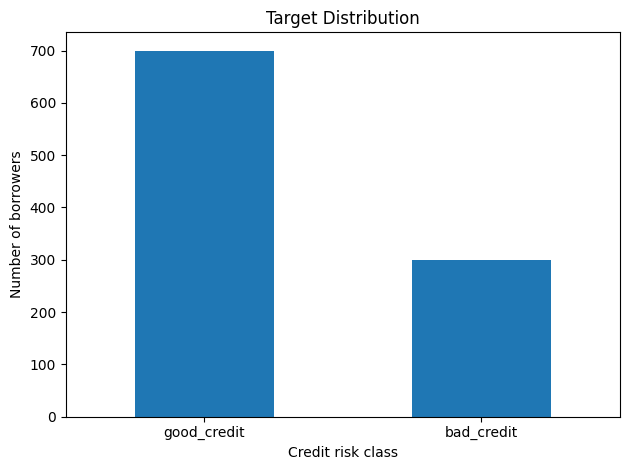

In [13]:

fig, ax = plt.subplots()

target_distribution["count"].plot(kind="bar", ax=ax)

ax.set_title("Target Distribution")
ax.set_xlabel("Credit risk class")
ax.set_ylabel("Number of borrowers")
ax.tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.show();



## Numerical feature analysis

This section reviews the distribution of numerical variables. The objective is to identify scale differences, skewness, extreme values, and variables that may require transformation during feature engineering.


In [14]:

df[numerical_features].describe().T


,count,mean,std,min,25%,50%,75%,max
duration_months,"1,000.0000",20.9030,12.0588,4.0000,12.0000,18.0000,24.0000,72.0000
credit_amount,"1,000.0000","3,271.2580","2,822.7369",250.0000,"1,365.5000","2,319.5000","3,972.2500","18,424.0000"
installment_rate_pct_income,"1,000.0000",2.9730,1.1187,1.0000,2.0000,3.0000,4.0000,4.0000
present_residence_since,"1,000.0000",2.8450,1.1037,1.0000,2.0000,3.0000,4.0000,4.0000
age_years,"1,000.0000",35.5460,11.3755,19.0000,27.0000,33.0000,42.0000,75.0000
existing_credits,"1,000.0000",1.4070,0.5777,1.0000,1.0000,1.0000,2.0000,4.0000
people_liable,"1,000.0000",1.1550,0.3621,1.0000,1.0000,1.0000,1.0000,2.0000


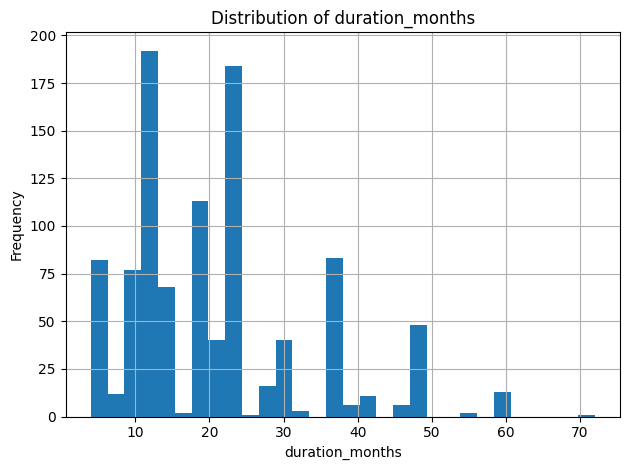

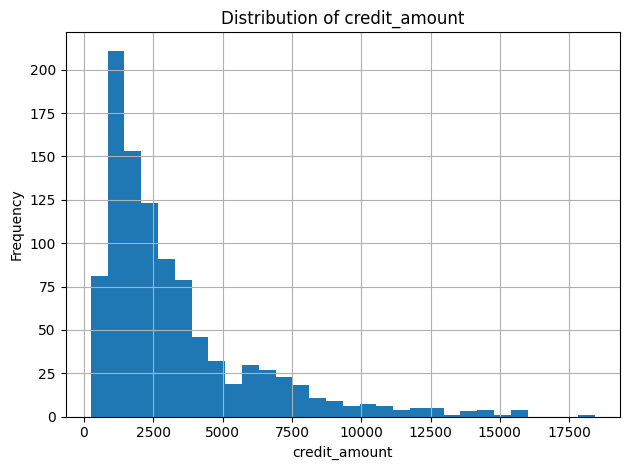

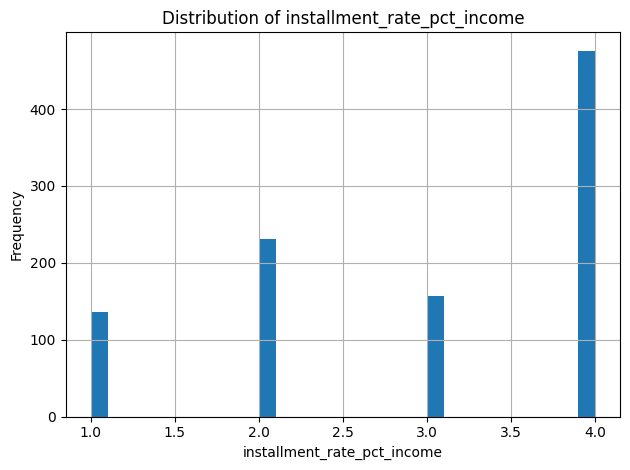

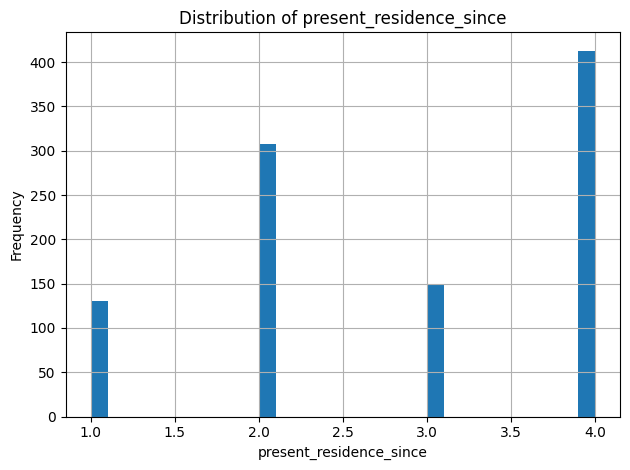

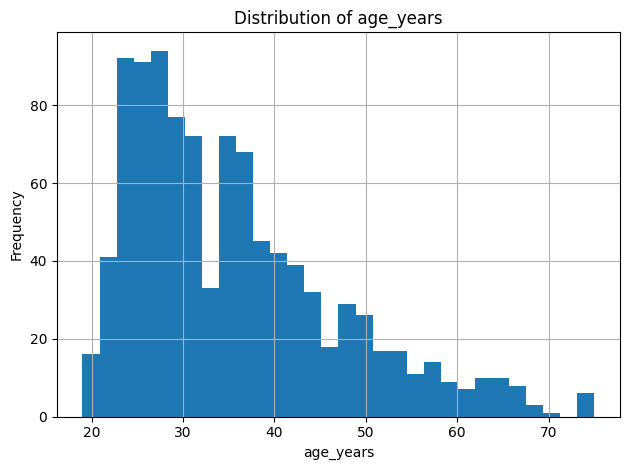

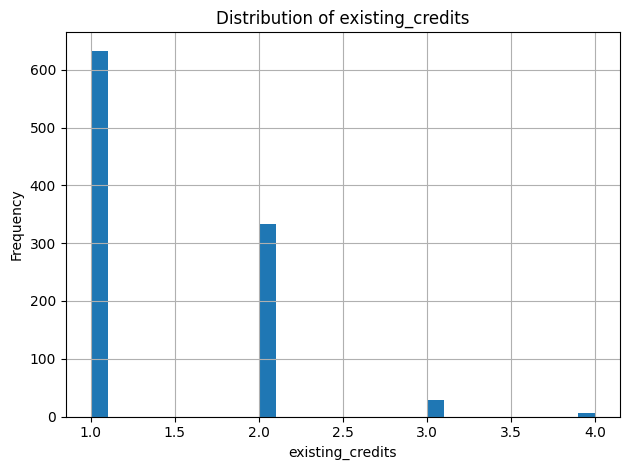

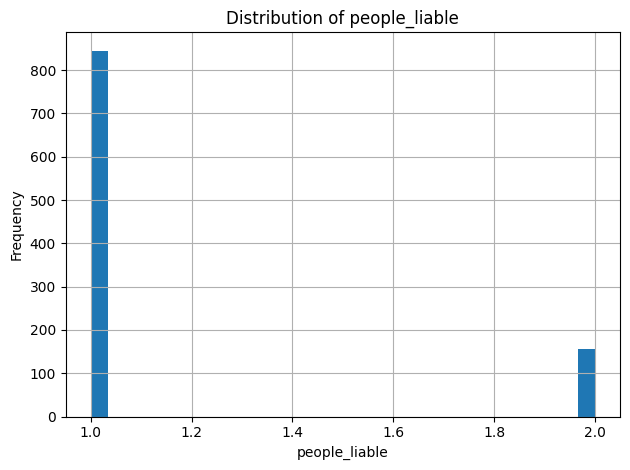

In [15]:

for col in numerical_features:
    fig, ax = plt.subplots()
    df[col].hist(bins=30, ax=ax)
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    plt.tight_layout()
    plt.show();



## Numerical features by credit risk class

A useful first risk signal appears when the distribution of a numerical variable differs meaningfully between good and bad credit borrowers.

The boxplots below are not final evidence of causality, but they help identify variables that may be predictive.


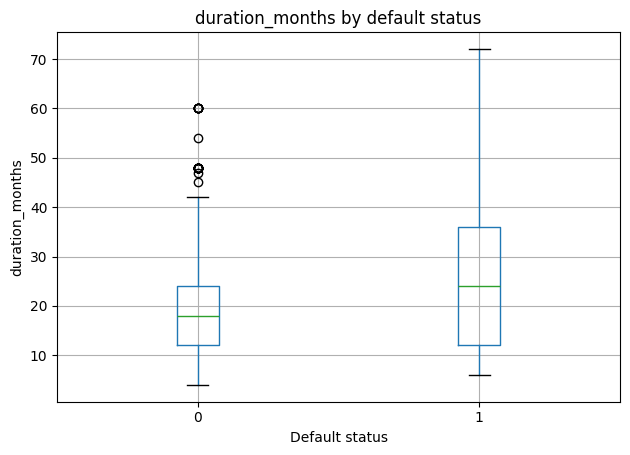

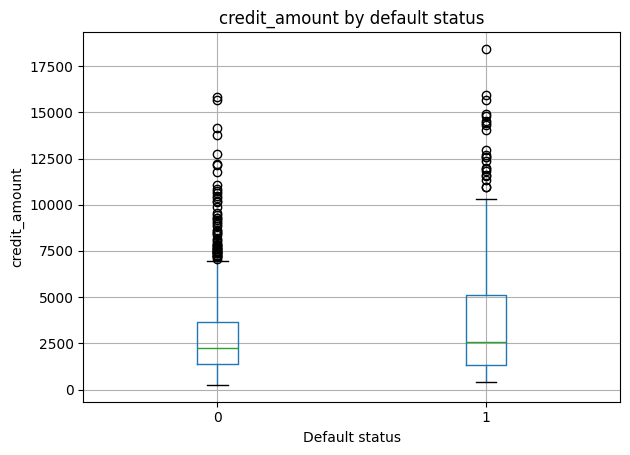

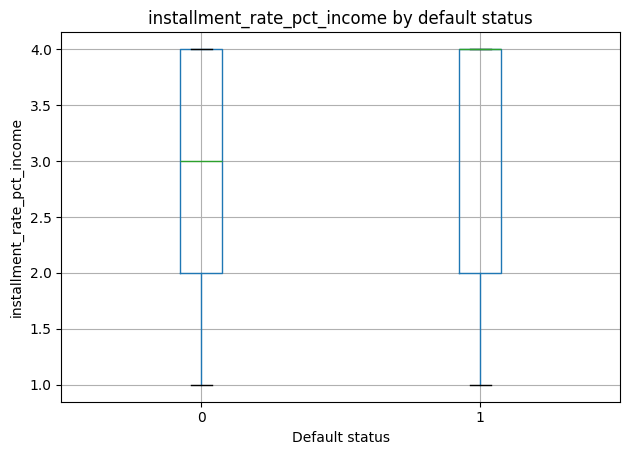

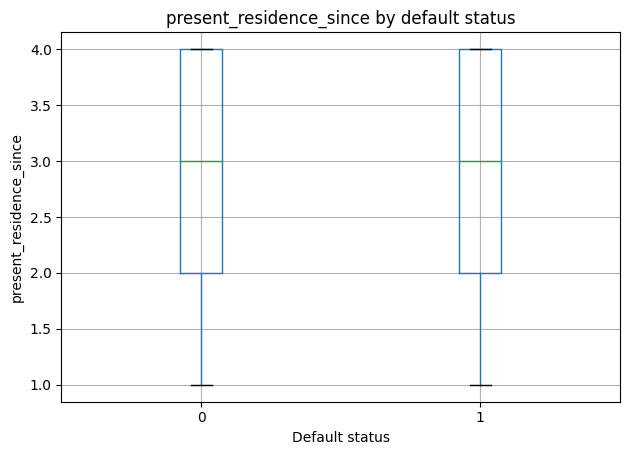

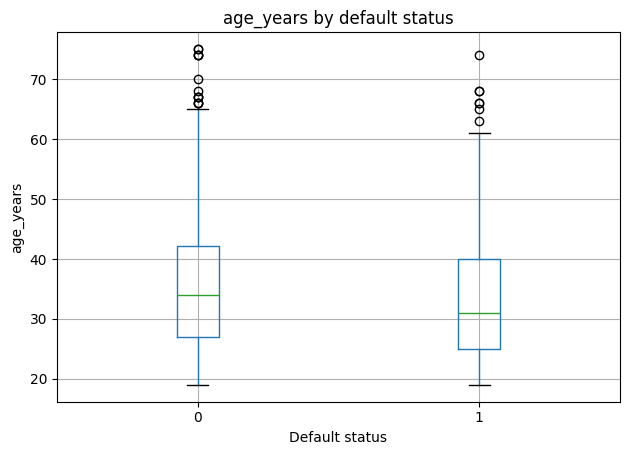

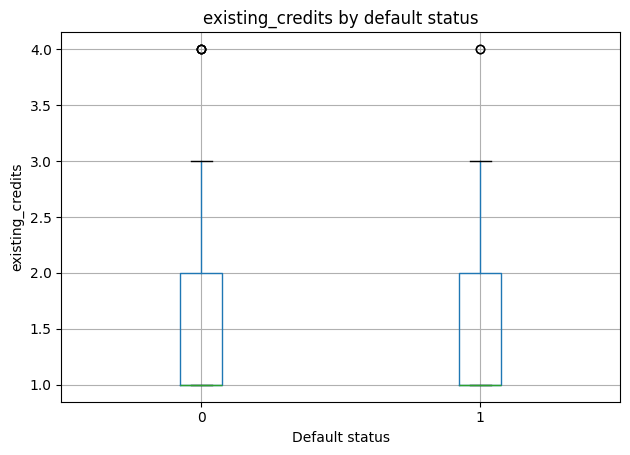

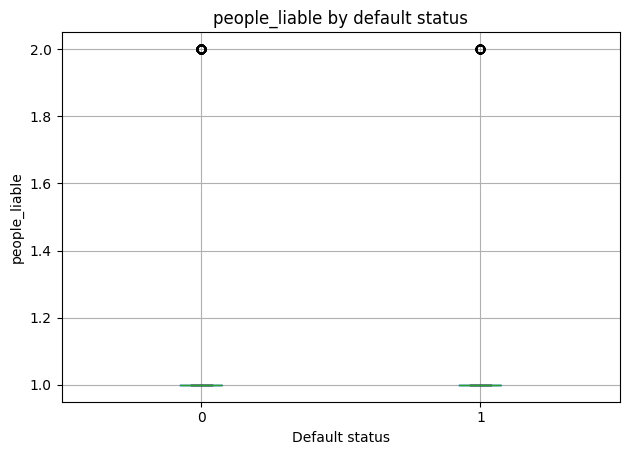

In [16]:

for col in numerical_features:
    fig, ax = plt.subplots()
    df.boxplot(column=col, by=target_col, ax=ax)
    ax.set_title(f"{col} by default status")
    ax.set_xlabel("Default status")
    ax.set_ylabel(col)
    plt.suptitle("")
    plt.tight_layout()
    plt.show();



## Correlation analysis

Correlation is useful for detecting linear relationships among numerical variables. In credit risk modeling, highly correlated predictors may create redundancy, especially in interpretable models such as logistic regression.


In [17]:

corr_matrix = df[numerical_features + [target_col]].corr()

corr_matrix


,duration_months,credit_amount,installment_rate_pct_income,present_residence_since,age_years,existing_credits,people_liable,default
duration_months,1.0000,0.6250,0.0747,0.0341,-0.0361,-0.0113,-0.0238,0.2149
credit_amount,0.6250,1.0000,-0.2713,0.0289,0.0327,0.0208,0.0171,0.1547
installment_rate_pct_income,0.0747,-0.2713,1.0000,0.0493,0.0583,0.0217,-0.0712,0.0724
present_residence_since,0.0341,0.0289,0.0493,1.0000,0.2664,0.0896,0.0426,0.0030
age_years,-0.0361,0.0327,0.0583,0.2664,1.0000,0.1493,0.1182,-0.0911
existing_credits,-0.0113,0.0208,0.0217,0.0896,0.1493,1.0000,0.1097,-0.0457
people_liable,-0.0238,0.0171,-0.0712,0.0426,0.1182,0.1097,1.0000,-0.0030
default,0.2149,0.1547,0.0724,0.0030,-0.0911,-0.0457,-0.0030,1.0000


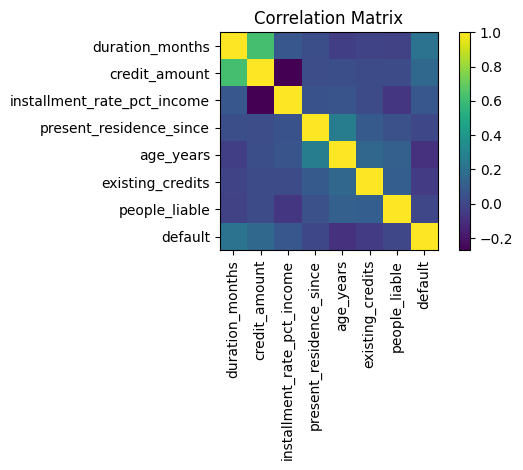

In [18]:

fig, ax = plt.subplots()

im = ax.imshow(corr_matrix)
ax.set_xticks(range(len(corr_matrix.columns)))
ax.set_yticks(range(len(corr_matrix.index)))
ax.set_xticklabels(corr_matrix.columns, rotation=90)
ax.set_yticklabels(corr_matrix.index)
ax.set_title("Correlation Matrix")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show();



## Categorical feature analysis

Categorical variables often contain important risk information. However, raw category codes are not always intuitive, so at this stage we focus on frequencies and default rates by category.

For every categorical feature, we calculate:

- Number of borrowers by category
- Default rate by category
- Share of the full portfolio represented by that category


In [19]:

def categorical_risk_summary(data: pd.DataFrame, feature: str, target: str = "default") -> pd.DataFrame:
    summary = (
        data
        .groupby(feature)
        .agg(
            borrowers=(target, "size"),
            defaults=(target, "sum"),
            default_rate=(target, "mean"),
        )
        .assign(portfolio_share=lambda x: x["borrowers"] / len(data))
        .sort_values("default_rate", ascending=False)
    )
    return summary

categorical_risk_summary(df, categorical_features[0], target_col)


,borrowers,defaults,default_rate,portfolio_share
checking_account_status,,,,
A11,274,135,0.4927,0.2740
A12,269,105,0.3903,0.2690
A13,63,14,0.2222,0.0630
A14,394,46,0.1168,0.3940


In [20]:

for col in categorical_features:
    print(f"\nFeature: {col}")
    display(categorical_risk_summary(df, col, target_col))



Feature: checking_account_status


,borrowers,defaults,default_rate,portfolio_share
checking_account_status,,,,
A11,274,135,0.4927,0.2740
A12,269,105,0.3903,0.2690
A13,63,14,0.2222,0.0630
A14,394,46,0.1168,0.3940



Feature: credit_history


,borrowers,defaults,default_rate,portfolio_share
credit_history,,,,
A30,40,25,0.6250,0.0400
A31,49,28,0.5714,0.0490
A32,530,169,0.3189,0.5300
A33,88,28,0.3182,0.0880
A34,293,50,0.1706,0.2930



Feature: purpose


...

,borrowers,defaults,default_rate,portfolio_share
job,,,,
A174,148,51,0.3446,0.1480
A171,22,7,0.3182,0.0220
A173,630,186,0.2952,0.6300
A172,200,56,0.2800,0.2000



Feature: telephone


,borrowers,defaults,default_rate,portfolio_share
telephone,,,,
A191,596,187,0.3138,0.5960
A192,404,113,0.2797,0.4040



Feature: foreign_worker


,borrowers,defaults,default_rate,portfolio_share
foreign_worker,,,,
A201,963,296,0.3074,0.9630
A202,37,4,0.1081,0.0370



## Default rate visualization by categorical feature

The following charts display default rates across categorical variables. These are useful to identify variables that may be relevant for risk segmentation and model interpretability.


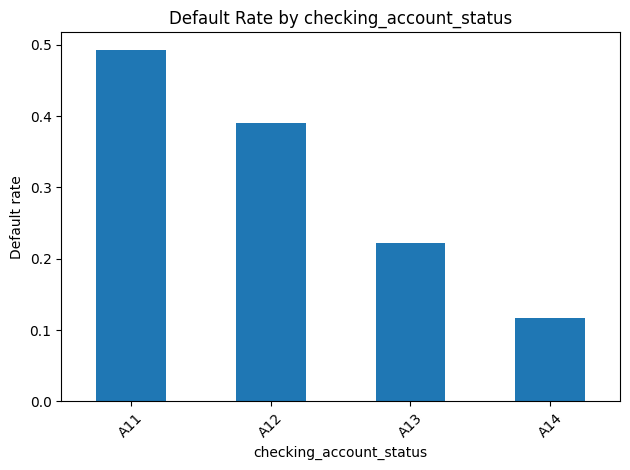

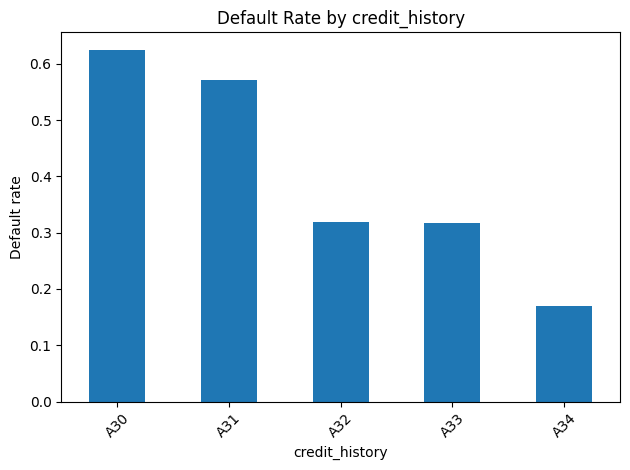

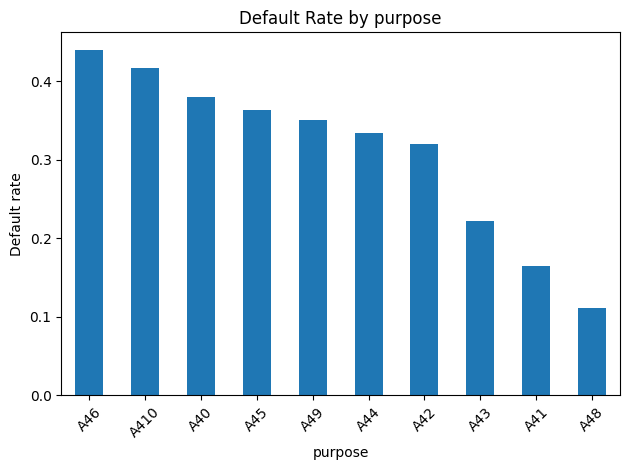

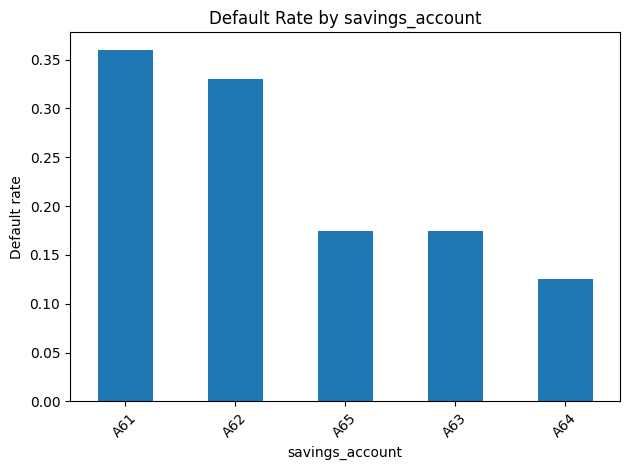

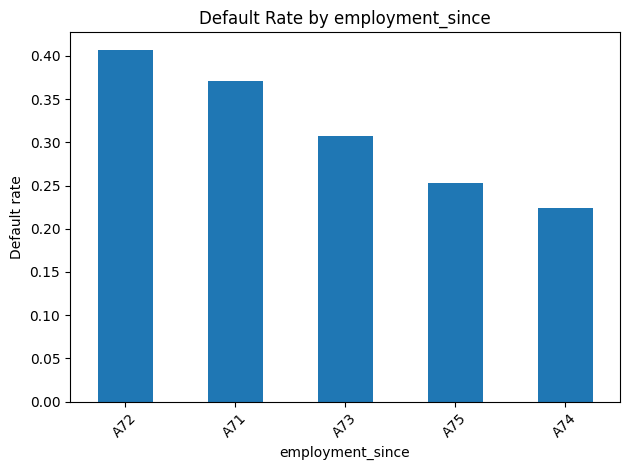

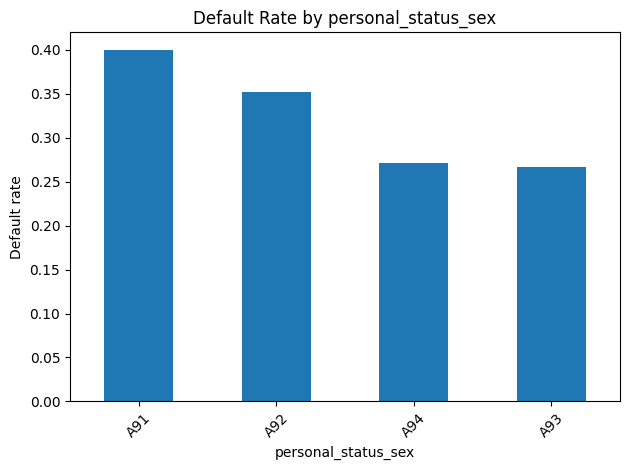

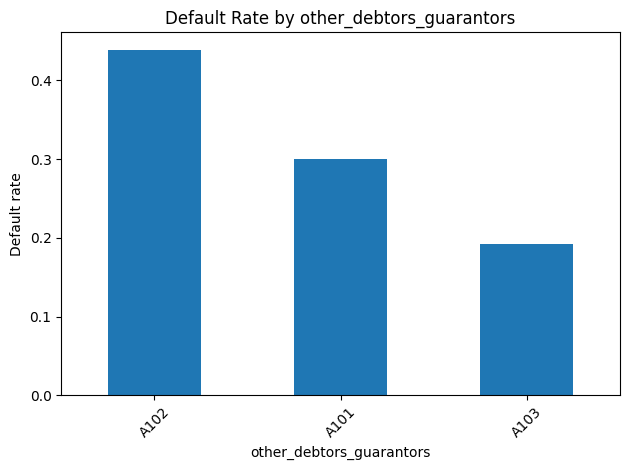

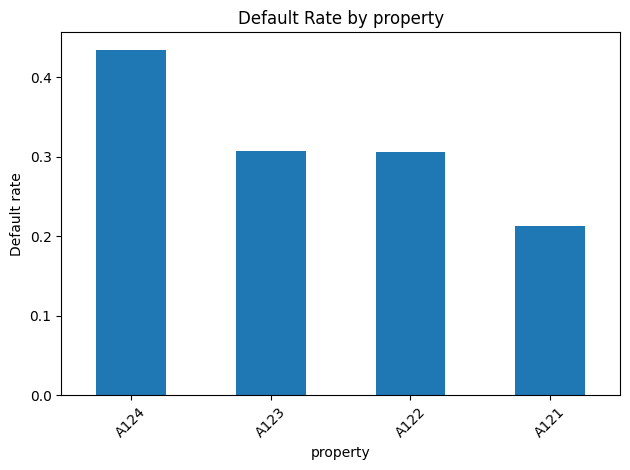

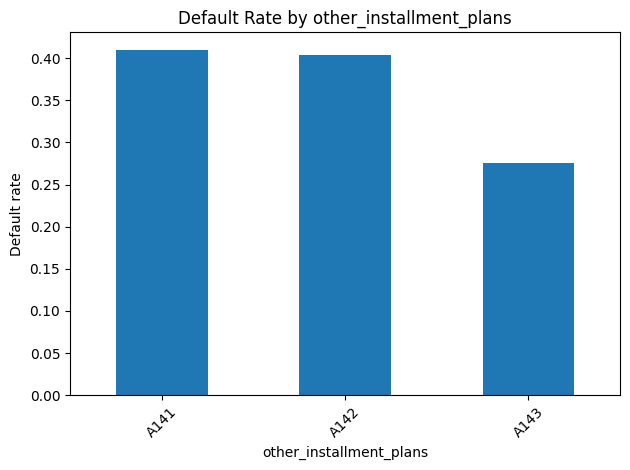

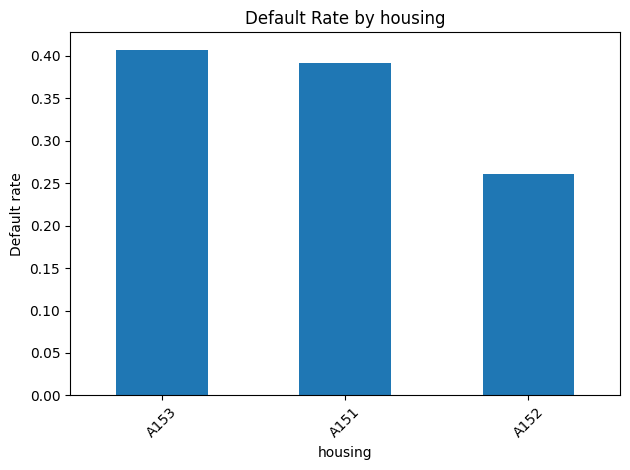

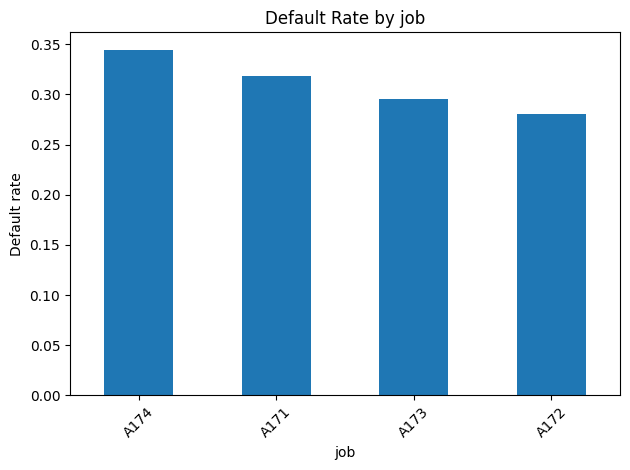

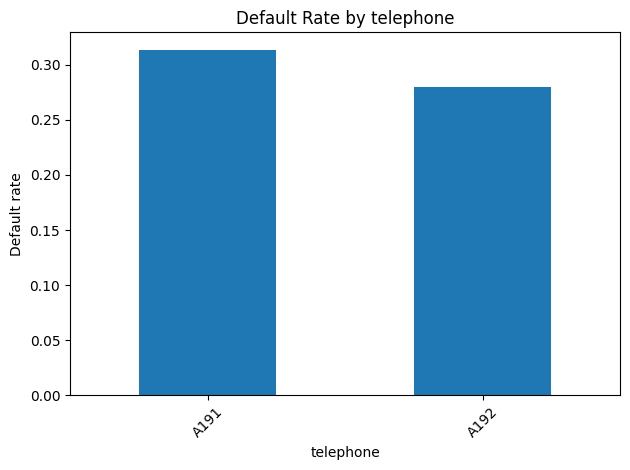

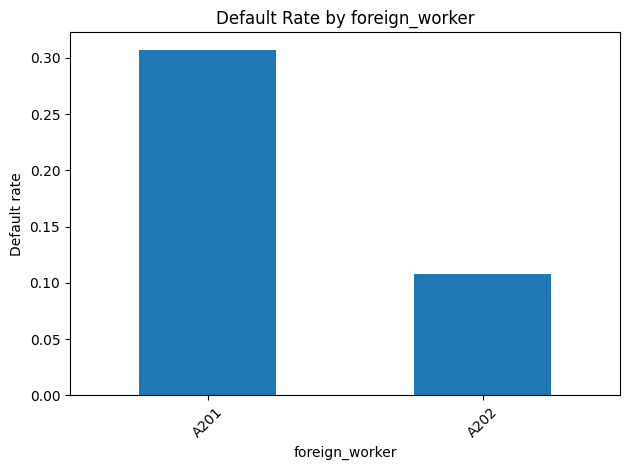

In [21]:

for col in categorical_features:
    summary = categorical_risk_summary(df, col, target_col)

    fig, ax = plt.subplots()
    summary["default_rate"].plot(kind="bar", ax=ax)

    ax.set_title(f"Default Rate by {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Default rate")
    ax.tick_params(axis="x", rotation=45)

    plt.tight_layout()
    plt.show();



## Early risk profile exploration

At this stage, we can build preliminary borrower profiles by combining a few intuitive variables. This is not yet a machine learning segmentation model, but it helps develop business intuition before applying unsupervised learning.

The next notebooks can formalize these patterns using clustering algorithms.


In [22]:

# Example: credit amount and duration as a simple risk profile
df["credit_amount_bucket"] = pd.qcut(
    df["credit_amount"],
    q=4,
    labels=["low_amount", "medium_low_amount", "medium_high_amount", "high_amount"]
)

df["duration_bucket"] = pd.qcut(
    df["duration_months"],
    q=4,
    labels=["short_duration", "medium_short_duration", "medium_long_duration", "long_duration"]
)

profile_summary = (
    df
    .groupby(["credit_amount_bucket", "duration_bucket"])
    .agg(
        borrowers=(target_col, "size"),
        default_rate=(target_col, "mean"),
        average_credit_amount=("credit_amount", "mean"),
        average_duration=("duration_months", "mean"),
    )
    .reset_index()
    .sort_values("default_rate", ascending=False)
)

profile_summary.head(10)


,credit_amount_bucket,duration_bucket,borrowers,default_rate,average_credit_amount,average_duration
7,medium_low_amount,long_duration,16,0.6875,"2,026.2500",34.3125
2,low_amount,medium_long_duration,30,0.5000,"1,162.5333",23.7333
12,high_amount,short_duration,17,0.4706,"7,022.1176",9.8235
15,high_amount,long_duration,153,0.4575,"7,826.6536",40.9085
13,high_amount,medium_short_duration,25,0.4000,"6,043.6800",17.0800
1,low_amount,medium_short_duration,45,0.3778,"1,063.1556",16.6222
11,medium_high_amount,long_duration,60,0.3500,"3,141.6667",35.6167
14,high_amount,medium_long_duration,55,0.3091,"6,209.3455",23.4909
6,medium_low_amount,medium_long_duration,57,0.2982,"1,799.8947",23.4386
5,medium_low_amount,medium_short_duration,63,0.2698,"1,765.4286",16.6508


In [23]:

pivot_profile = profile_summary.pivot(
    index="credit_amount_bucket",
    columns="duration_bucket",
    values="default_rate"
)

pivot_profile


duration_bucket,short_duration,medium_short_duration,medium_long_duration,long_duration
credit_amount_bucket,,,,
low_amount,0.2586,0.3778,0.5000,0.0000
medium_low_amount,0.1491,0.2698,0.2982,0.6875
medium_high_amount,0.1111,0.2222,0.2073,0.3500
high_amount,0.4706,0.4000,0.3091,0.4575


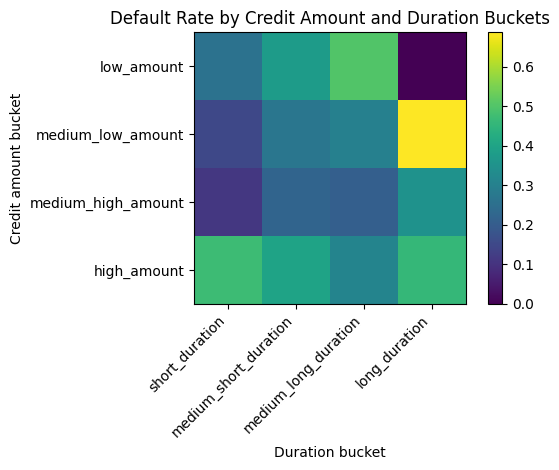

In [24]:

fig, ax = plt.subplots()

im = ax.imshow(pivot_profile)

ax.set_xticks(range(len(pivot_profile.columns)))
ax.set_yticks(range(len(pivot_profile.index)))
ax.set_xticklabels(pivot_profile.columns, rotation=45, ha="right")
ax.set_yticklabels(pivot_profile.index)

ax.set_title("Default Rate by Credit Amount and Duration Buckets")
ax.set_xlabel("Duration bucket")
ax.set_ylabel("Credit amount bucket")

fig.colorbar(im, ax=ax)
plt.tight_layout()
plt.show();



## Basic analytical conclusions

Use this section to summarize what was observed during the exploratory analysis.

At this point, the conclusions should remain careful and descriptive. The purpose is not to claim final predictive relationships, but to document early evidence that will inform the modeling strategy.

Suggested points to complete after running the notebook:

- Is the default class balanced or imbalanced?
- Which numerical variables show the strongest differences across default status?
- Which categorical variables show high default-rate variation?
- Are there variables that may require encoding, transformation, or binning?
- Are there data quality issues that must be handled before modeling?
- What patterns may be useful for unsupervised segmentation?


In [25]:

eda_summary = {
    "n_rows": df.shape[0],
    "n_columns": df.shape[1],
    "default_rate": df[target_col].mean(),
    "missing_values_total": int(df.isna().sum().sum()),
    "duplicated_rows": int(df.duplicated().sum()),
    "n_numerical_features": len(numerical_features),
    "n_categorical_features": len(categorical_features),
}

eda_summary


{'n_rows': 1000,
 'n_columns': 24,
 'default_rate': np.float64(0.3),
 'missing_values_total': 0,
 'duplicated_rows': 0,
 'n_numerical_features': 7,
 'n_categorical_features': 13}


## Save a clean analytical copy

The raw data remains stored in `data/raw/`. For the next notebook, we save a first analytical version in `data/processed/`.

This file is not yet fully engineered for machine learning. It only includes the transformed target and the basic variables prepared during the exploratory analysis.


In [26]:

processed_file = DATA_PROCESSED / "german_credit_eda.csv"

df.to_csv(processed_file, index=False)

print(f"Processed EDA dataset saved to: {processed_file}")


Processed EDA dataset saved to: /Users/andremgx/Documents/GitHub/credit-risk-intelligence-lab/data/processed/german_credit_eda.csv



## Next steps

The next notebook should focus on **feature engineering**.

Recommended next tasks:

1. Encode categorical variables.
2. Scale numerical variables when needed.
3. Create financial risk features such as credit amount per month, age buckets, duration buckets, and exposure proxies.
4. Prepare a clean modeling dataset.
5. Define a reproducible train-test split.
6. Build a preprocessing pipeline that can be reused by supervised and unsupervised models.

The natural next file is:

```text
notebooks/02_feature_engineering.ipynb
```
